### WS 2020/21 <span style="float: right;">GET Lab<br />Paderborn University</span><br />
## <center>Digital Image Processing I<br /><br />Task Sheet 5</center>
---

### Overview

The main objective of this exercise is to study histogram processing, which is particularly useful for image enhancement. Depending on the specific method, the information required can usually be extracted *automatically* from the image data, so that it is not necessary to specify any parameters. One of the most common methods in this context is histogram equilization, where the distribution of the gray values in the output image should have a uniform distribution.

The following figure illustrates the idea:

<br />
<center><img src="images/histogram-equilization.png" width="800px" /></center>

---

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

dpi = plt.rcParams['figure.dpi']

# plot grayscale image in original size
def plot_img_orig(img):
    rows, cols = img.shape # image size
    fig = plt.figure(figsize = (cols/dpi, rows/dpi))
    fig.add_axes([0, 0, 1, 1])
    plt.axis('off')
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.show()

#### <span style="color: RoyalBlue; font-weight: bold;">Task 5.1</span> Histogram Computation and Analysis

As computing histograms is a standard task, many program libraries (for example, Numpy) provide functions for this. Nonetheless, writing a custom function helps to understand the workflow of the program libraries. In this example, an image of pollen particles taken with a scanning electron microscope is considered. The image is available in four variants (pollen-var1.png - pollen-var4.png, shown smaller here for overview):

<img src="images/pollen-var1.png" width="200px"> <img src=images/pollen-var2.png width="200px"> <img src="images/pollen-var3.png" width="200px"> <img src="images/pollen-var4.png" width="200px"><br />

Implement the following tasks:
1. Write a function to compute the histogram of a given grayscale image.
2. Read an image (pollen-var1.png from the folder *images*) as a grayscale image and compute the histogram using this function.
3. Plot the histogram based on your function.
4. Compare the results with the function <a href="https://numpy.org/doc/stable/reference/generated/numpy.histogram.html">`hist` ↗</a> from matplotlib (use <a href="https://numpy.org/doc/stable/reference/generated/numpy.ndarray.flatten.html">`flatten` ↗</a> on the image at first to get the 1D histogram).
5. Characterize the four images (pollen-var1.png - pollen-var4.png from the folder *images*) based on their histograms.


In [3]:
# write your code here

# compute histogram of given image
def compute_histogram(img):
    rows, cols = img.shape # image size
    
    # list to save frequency of each gray value
    hist = np.zeros(256, dtype=np.float64)

    for row in range(rows):
        for col in range(cols):
            curr = img[row, col]
            hist[curr] +=1
    
    return hist
    # ...

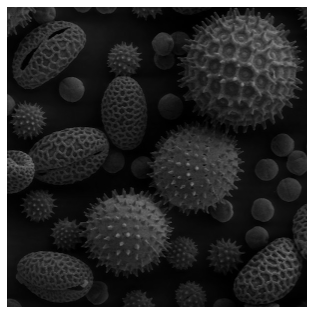

In [4]:
img = cv2.imread('images/pollen-var1.png', 0)
plot_img_orig(img)

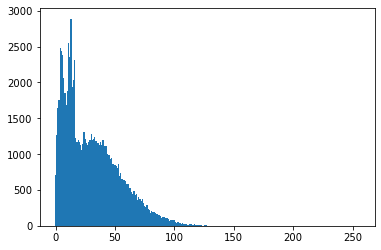

In [12]:
img_hist = compute_histogram(img)
val = np.arange(256)
plt.bar(val, img_hist, 1)
plt.show()

#### <span style="color: RoyalBlue; font-weight: bold;">Task 5.2</span> Histogram Equalization

Implement / solve the following tasks:

1. Write a function to apply histogram equalization to a given grayscale image.
2. Apply the histogram equalization to the four images (pollen-var1.png - pollen-var4.png from the folder *images*) and plot the results.
3. Compare the histograms of the equalized images with the histograms from the previous task. Are the distributions of the output images uniform?
4. Plot the four transfer functions $T(r_k)$ in one diagram and analyze them with regard to the histograms.
5. What happens when using a checkerboard? Test it (use checkerboard.png from the folder *images*).

In [17]:
# write your code here

# apply histogram equalization to given image
def histogram_equalization(img):
    rows, cols = img.shape # image size

    hist = compute_histogram(img)
    hist_norm = hist/(rows*cols)

    tf = np.zeros(256, dtype=np.float64)
    for i in range(hist_norm.size):
        tf[i] = 255 * sum(hist_norm[0:i+1])

    res = np.zeros(shape=[rows, cols], dtype=np.uint8)
    
    for row in range(rows):
        for col in range(cols):
            res[row, col] = tf[img[row, col]]

    return res, tf          
    
    # ...

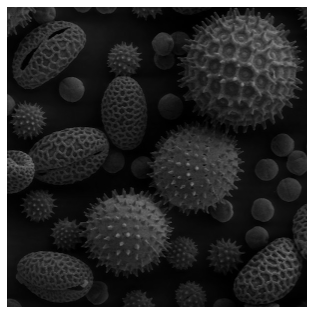

In [27]:
img1 = cv2.imread('images/pollen-var1.png', 0)
plot_img_orig(img1)

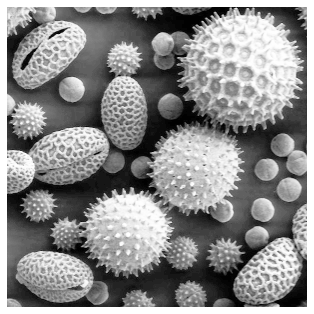

In [28]:
img1_hist_eq, tf = histogram_equalization(img1)
plot_img_orig(img1_hist_eq)

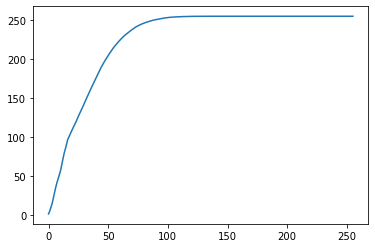

In [29]:
plt.plot(tf)

In [30]:
print(tf)

[  1.99183333   5.58166667  10.251       15.20366667  22.23883333
  29.13233333  35.887       41.72933333  46.97383333  51.72816667
  57.0435      64.26283333  70.924       79.10666667  84.575
  90.3465      96.88583333 100.3595     103.68866667 107.08866667
 110.39516667 113.58266667 116.58883333 119.81316667 123.52766667
 126.97016667 130.23133333 133.42166667 136.71966667 140.11966667
 143.75766667 147.14066667 150.56616667 154.0625     157.3945
 160.6585     163.948      167.15533333 170.459      173.64366667
 177.04933333 180.21416667 183.362      186.5325     189.3715
 192.1595     194.80016667 197.46916667 199.92566667 202.385
 204.77066667 207.145      209.42866667 211.85966667 213.8175
 215.9085     217.74733333 219.5465     221.34       223.11366667
 224.77683333 226.41733333 227.91333333 229.398      230.72683333
 231.965      233.32783333 234.55466667 235.80416667 236.84116667
 237.98866667 239.06533333 240.04       241.09683333 241.99216667
 242.777      243.53066667 244.3

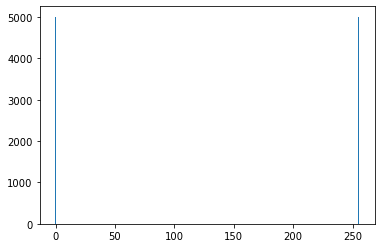

In [36]:
img = cv2.imread('images/checkerboard-small.png', 0)
img_hist = compute_histogram(img)
val = np.arange(256)
plt.bar(val, img_hist, 1)
plt.show()


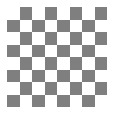

In [37]:
res, tf = histogram_equalization(img)
plot_img_orig(res)

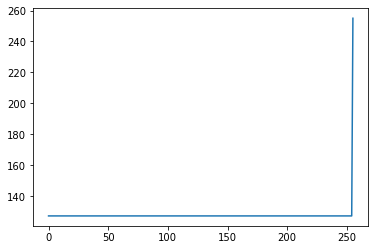

In [32]:
plt.plot(tf)

In [33]:
print(tf)

[127.296 127.296 127.296 127.296 127.296 127.296 127.296 127.296 127.296
 127.296 127.296 127.296 127.296 127.296 127.296 127.296 127.296 127.296
 127.296 127.296 127.296 127.296 127.296 127.296 127.296 127.296 127.296
 127.296 127.296 127.296 127.296 127.296 127.296 127.296 127.296 127.296
 127.296 127.296 127.296 127.296 127.296 127.296 127.296 127.296 127.296
 127.296 127.296 127.296 127.296 127.296 127.296 127.296 127.296 127.296
 127.296 127.296 127.296 127.296 127.296 127.296 127.296 127.296 127.296
 127.296 127.296 127.296 127.296 127.296 127.296 127.296 127.296 127.296
 127.296 127.296 127.296 127.296 127.296 127.296 127.296 127.296 127.296
 127.296 127.296 127.296 127.296 127.296 127.296 127.296 127.296 127.296
 127.296 127.296 127.296 127.296 127.296 127.296 127.296 127.296 127.296
 127.296 127.296 127.296 127.296 127.296 127.296 127.296 127.296 127.296
 127.296 127.296 127.296 127.296 127.296 127.296 127.296 127.296 127.296
 127.296 127.296 127.296 127.296 127.296 127.296 12

#### <span style="color: RoyalBlue; font-weight: bold;">Task 5.3</span> Local Histogram Equalization

The global histogram equalization from the previous tasks is suitable for an overall enhancement of images, but often fails to enhance details in small image areas. For this purpose, the histogram equalization can be applied to a local neighborhood of each pixel. At each location, the corresponding transfer function can be applied to the pixel in the center of the neighborhood. In this example, an image with hidden symbols is considered. Furthermore, the image contains some background noise.

Implement / solve the following tasks:

1. Read an image (squares.png from the folder *images*) as a grayscale image and plot it.
2. Apply global histogram equalization to the image and plot the result.
3. Write a function to apply local histogram equalization to a given grayscale image using $N\times N$ windows ($N$ should be odd).
4. Apply this function to the image using $N = 3$, then plot and analyze the results.
5. What happens when using a checkerboard? Test it (use checkerboard-small.png from the folder *images*).

*Note*: When implementing neighborhood operations it is necessary to consider what happens when approaching the border of the image. In this example, the border can just be left out.

In [ ]:
# write your code here

# apply local histogram equalization to given image using NxN windows (odd N required)
def local_histogram_equalization(img, n):
    rows, cols = img.shape # image size
    
    # ...

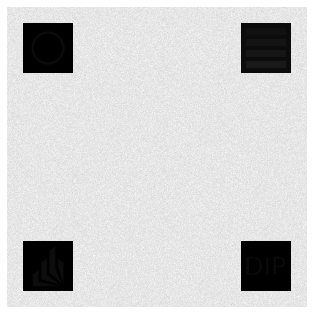

In [38]:
img = cv2.imread('images/squares.png', 0)
plot_img_orig(img)


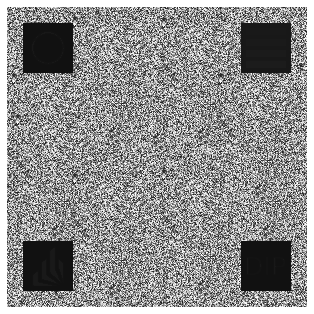

In [40]:
res, tf = histogram_equalization(img)
plot_img_orig(res)

In [49]:
def local_histogram_equalization(img, n):
    rows, cols = img.shape

    res = np.zeros(shape=[rows, cols], dtype=np.uint8)

    h = int(n/2)

    for row in range(h, rows-1):
        for col in range(h, cols-h):
            nbh = img[col-h:col+h+1, row-h:row+h+1]
            res_he, tf = histogram_equalization(nbh)

            res[col, row] = tf[img[col, row]]
    return res

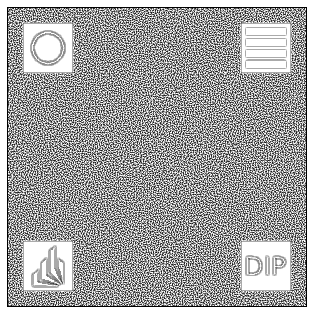

In [50]:
res_local = local_histogram_equalization(img, 3)
plot_img_orig(res_local)